In [1]:
import os, ujson as json, numpy as np
from matplotlib import pyplot as plt

experiments = sorted([exp for exp in os.listdir("../mtco_old/experiments") if exp.startswith("exp")])

print(len(experiments))

exp_results = []
for exp in experiments:
    if not os.path.exists(f"../mtco_old/experiments/{exp}/args.json") or not os.path.exists(f"../mtco_old/experiments/{exp}/logs.jsonl"):
        continue

    with open(f"../mtco_old/experiments/{exp}/args.json", "r") as f:
        exp_args = json.load(f)

    learning_rate = exp_args["learning_rate"]
    if "group_size" not in exp_args:
        continue
    group_size = exp_args["group_size"]

    exp_logs = []
    with open(f"../mtco_old/experiments/{exp}/logs.jsonl", "r") as f:
        for line in f:
            exp_logs.append(json.loads(line))

    task_id = exp_args["task_id"]

    if "num_unique_correct_answers" not in exp_logs[0]:
        continue

    with open(f"../mtco_old/experiments/{exp}/unique_answers.jsonl", "r") as f:
        unique_answers = [json.loads(line) for line in f]

    already_seen_answers = set()
    num_new_answers = []
    for answers in unique_answers:
        this_answers = set(answers)
        new_answers = this_answers - already_seen_answers
        num_new_answers.append(len(new_answers))
        already_seen_answers |= this_answers


    # mean_train_score = [log["mean_train_score"] for log in exp_logs]
    mean_eval_score = [log["mean_eval_score"] for log in exp_logs]
    # if mean_eval_score[-1] < 0.99:
    #     continue # didn't reach the 99% objective
    uniqueness = [log["uniqueness"]/100.0 for log in exp_logs]

    correct_logprobs = [np.mean(log["correct_logprobs"]) for log in exp_logs]
    incorrect_logprobs = [np.mean(log["incorrect_logprobs"]) for log in exp_logs]
    num_unique_correct_answers = [log["num_unique_correct_answers"] for log in exp_logs]

    exp_results.append({"task_id": task_id, "mean_eval_score": mean_eval_score, "uniqueness": uniqueness, "learning_rate": learning_rate, "group_size": group_size, "correct_logprobs": correct_logprobs, "incorrect_logprobs": incorrect_logprobs, "num_unique_correct_answers": num_unique_correct_answers, "num_new_answers": num_new_answers})
    # plot these things on a row with 3 columns: (1) (mean_eval_score and uniqueness), (2) (correct_logprobs and incorrect_logprobs), (3) (num_unique_correct_answers)

    iterations = list(range(len(mean_eval_score)))

    # fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # axes[0].plot(iterations, mean_eval_score, label="Mean Eval Score")
    # axes[0].plot(iterations, uniqueness, label="Uniqueness")
    # axes[0].set_xlabel("Iteration")
    # axes[0].set_ylabel("Score")
    # axes[0].set_title(f"Mean Eval Score and Uniqueness")
    # axes[0].legend()

    # # plot the logprobs on a log scale
    # axes[1].plot(iterations, correct_logprobs, label="Correct Logprobs")
    # axes[1].plot(iterations, incorrect_logprobs, label="Incorrect Logprobs")
    # axes[1].set_xlabel("Iteration")
    # axes[1].set_ylabel("Logprobs")
    # axes[1].set_title(f"Correct and Incorrect Logprobs")
    # axes[1].legend()

    # axes[2].plot(iterations, num_unique_correct_answers, label="Num Unique Correct Answers")
    # axes[2].plot(iterations, num_new_answers, label="Num Novel Correct Answers")
    # axes[2].set_xlabel("Iteration")
    # axes[2].set_ylabel("Number of Unique Correct Answers")
    # axes[2].legend()

    # # suptitle
    # print(f"Task {task_id}; Degree {degree}; Learning Rate {learning_rate}")

    # plt.tight_layout()
    # plt.show()


403


/home/plaban/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/plaban/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


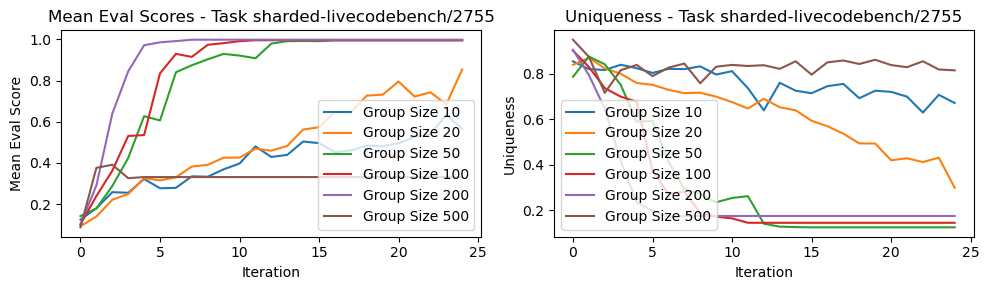

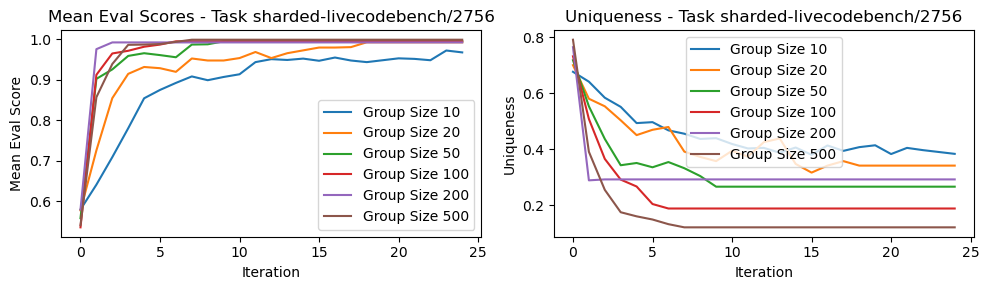

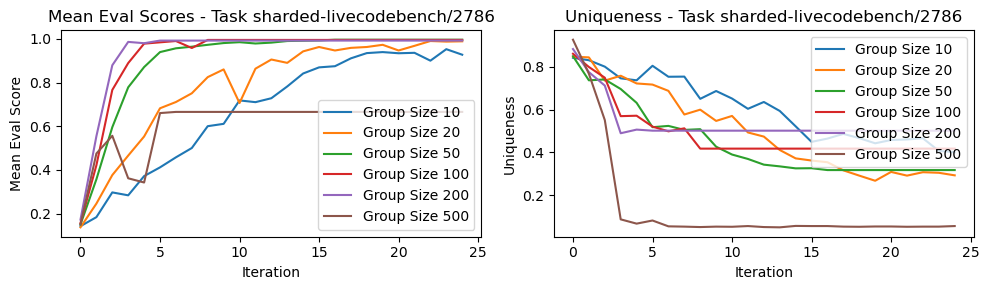

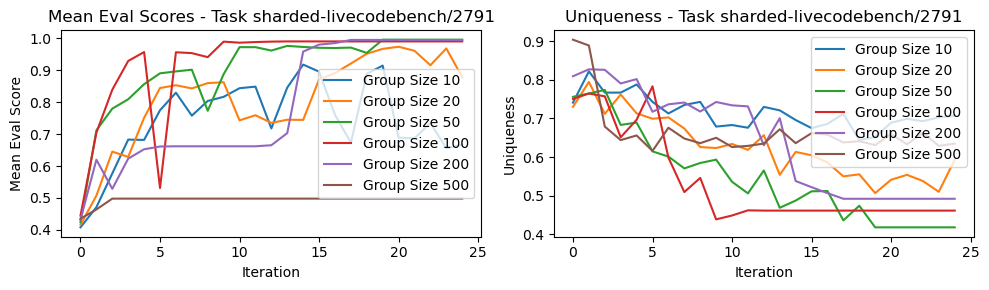

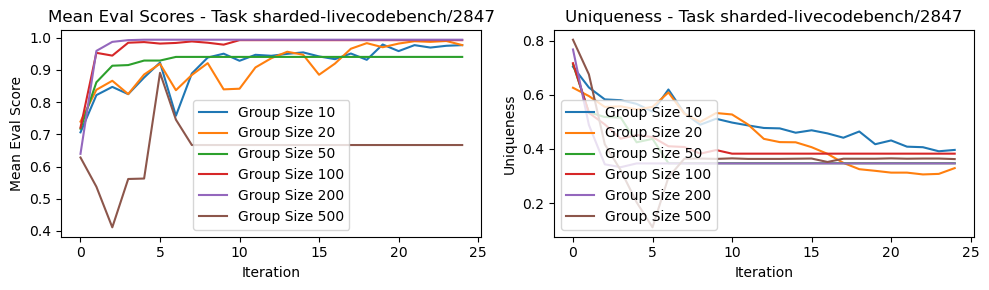

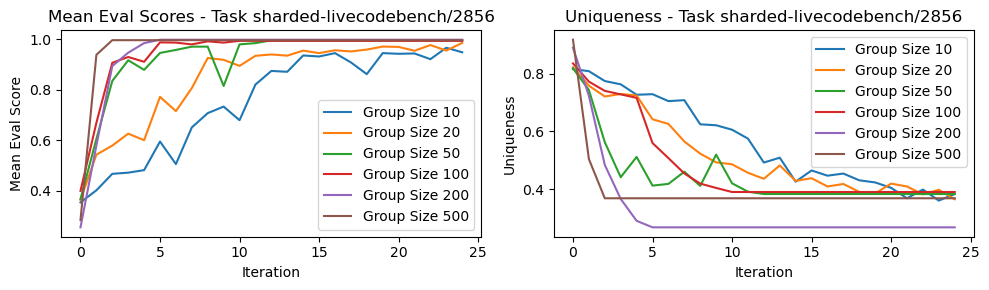

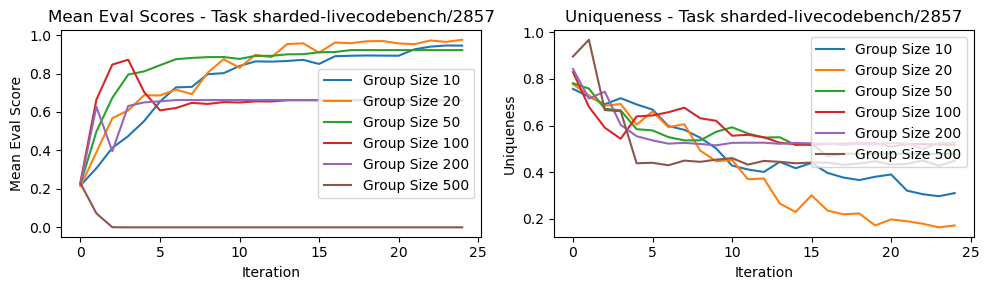

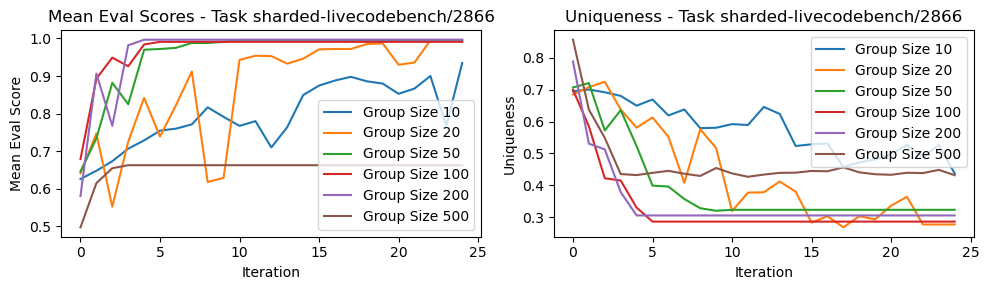

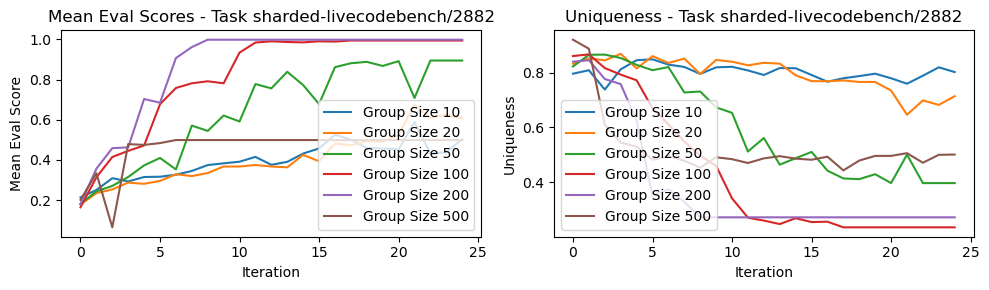

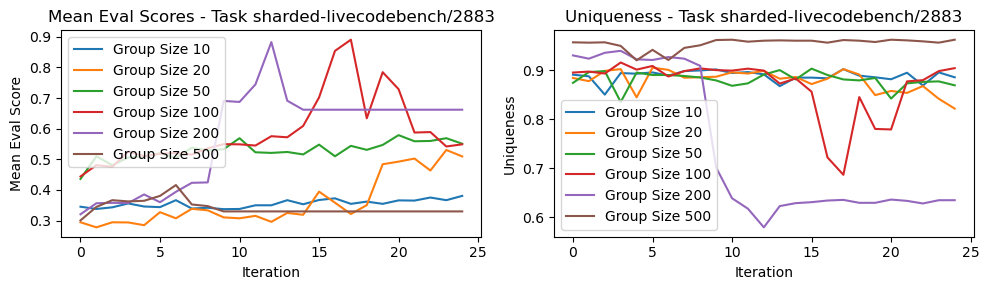

In [4]:
from matplotlib import pyplot as plt
import numpy as np

group_sizes = sorted(list(set([res["group_size"] for res in exp_results])))
task_ids = sorted(list(set([res["task_id"] for res in exp_results])))

max_iter = 25
for task_id in task_ids:
    all_mean_eval_scores, all_uniquenesses = {}, {}
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for group_size in group_sizes:
        all_mean_eval_scores[group_size], all_uniquenesses[group_size] = [], []
        this_results = [res for res in exp_results if res["task_id"] == task_id and res["group_size"] == group_size]

        this_mean_eval_scores = []
        this_uniquenesses = []

        for res in this_results:
            mean_eval_score = res["mean_eval_score"][:max_iter]
            if len(mean_eval_score) < max_iter:
                mean_eval_score += [mean_eval_score[-1]] * (max_iter - len(mean_eval_score))
            
            uniqueness = res["uniqueness"][:max_iter]
            if len(uniqueness) < max_iter:
                uniqueness += [uniqueness[-1]] * (max_iter - len(uniqueness))

            all_mean_eval_scores[group_size].append(mean_eval_score)
            all_uniquenesses[group_size].append(uniqueness)
    
    for group_size in group_sizes:
        mean_eval_scores = np.mean(all_mean_eval_scores[group_size], axis=0)
        uniquenesses = np.mean(all_uniquenesses[group_size], axis=0)
        axes[0].plot(mean_eval_scores, label=f"Group Size {group_size}")
        axes[1].plot(uniquenesses, label=f"Group Size {group_size}")
    
    axes[0].legend()
    axes[0].set_title(f"Mean Eval Scores - Task {task_id}")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Mean Eval Score")
    
    axes[1].legend()
    axes[1].set_title(f"Uniqueness - Task {task_id}")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Uniqueness")
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Calculate grid dimensions
num_plots = len(exp_results)
num_cols = 8
num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))

# Flatten axes array for easier iteration
if num_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot each experiment
for idx, result in enumerate(exp_results):
    ax = axes_flat[idx]
    ax.plot(result["mean_eval_score"], label="Mean Eval Score")
    ax.plot(result["uniqueness"], label="Uniqueness")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title(f"Task {result['task_id']}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")

# Hide any unused subplots
for idx in range(num_plots, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


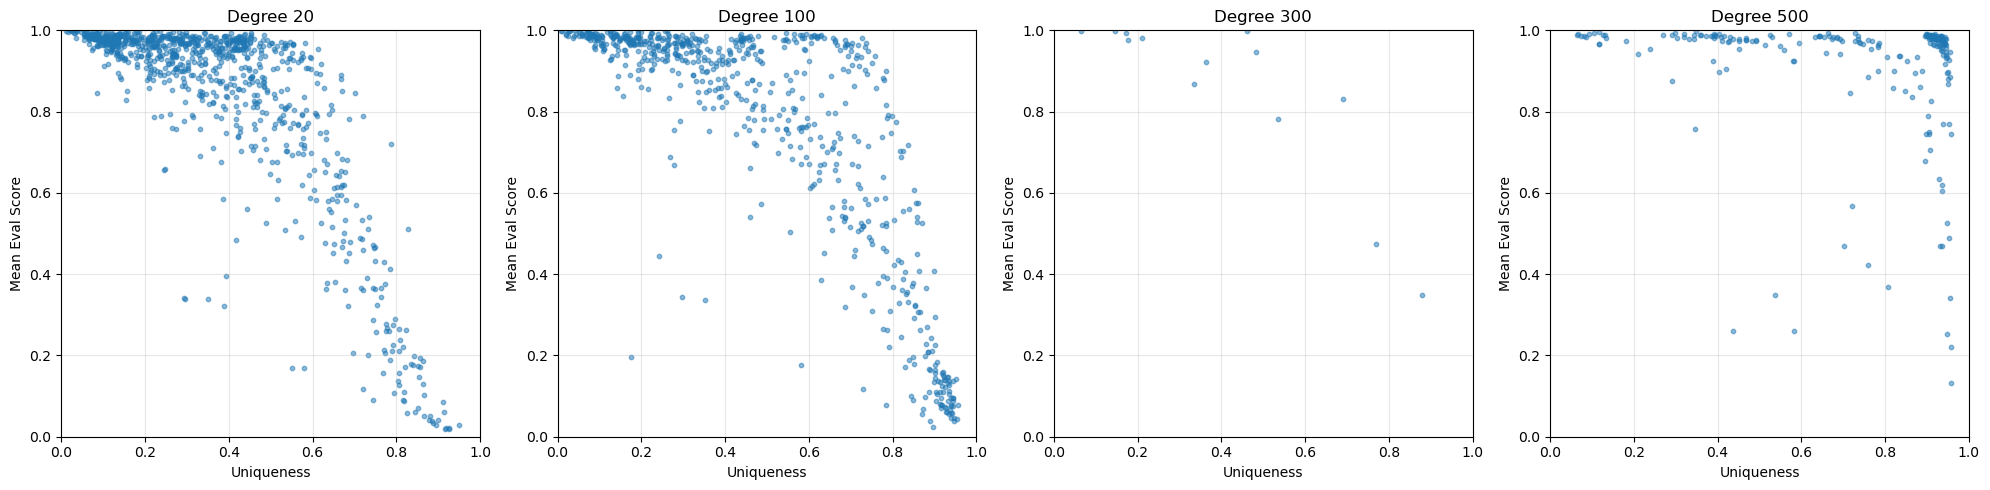

In [15]:
# Group data by degree and collect all (uniqueness, mean_eval_score) pairs
from collections import defaultdict

degree_data = defaultdict(lambda: {"uniqueness": [], "mean_eval_score": []})

for result in exp_results:
    degree = result["degree"]
    # Collect all points from all iterations
    for u, score in zip(result["uniqueness"], result["mean_eval_score"]):
        degree_data[degree]["uniqueness"].append(u)
        degree_data[degree]["mean_eval_score"].append(score)

# Create scatter plots, one for each degree
degrees = sorted(degree_data.keys())
num_degrees = len(degrees)
num_cols = min(4, num_degrees)
num_rows = (num_degrees + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

# Handle single plot case
if num_degrees == 1:
    axes = [axes]
else:
    axes = axes.flatten() if num_degrees > 1 else [axes]

# Plot scatter for each degree
for idx, degree in enumerate(degrees):
    ax = axes[idx] if num_degrees > 1 else axes[0]
    data = degree_data[degree]
    ax.scatter(data["uniqueness"], data["mean_eval_score"], alpha=0.5, s=10)
    ax.set_xlabel("Uniqueness")
    ax.set_ylabel("Mean Eval Score")
    ax.set_title(f"Degree {degree}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
if num_degrees > 1:
    for idx in range(num_degrees, len(axes)):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()
